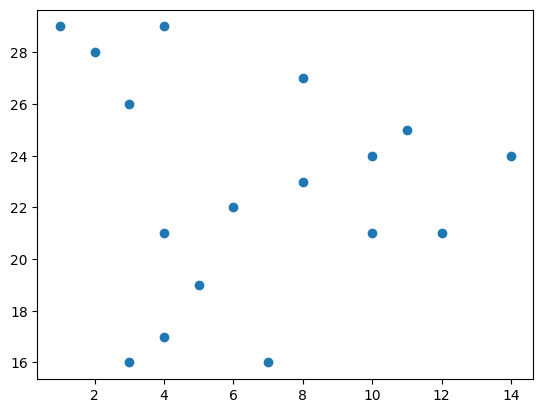

In [2]:
import matplotlib.pyplot as plt

x = [4, 5, 10, 4, 3, 11, 14 , 6, 10, 12, 8, 8, 7, 4, 3, 2, 1]
y = [21, 19, 24, 17, 16, 25, 24, 22, 21, 21, 23, 27, 16, 29, 26, 28, 29]

plt.scatter(x, y)
plt.show()

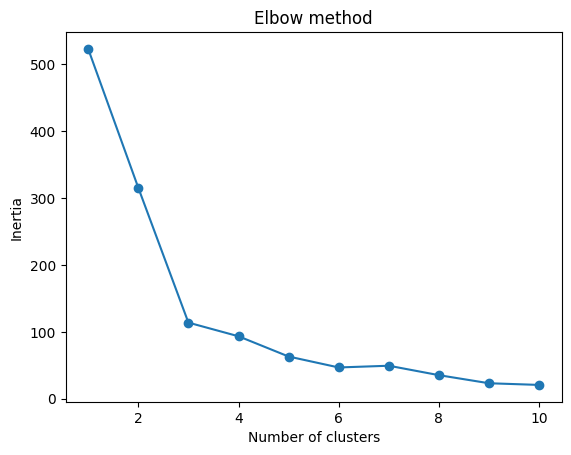

In [3]:
from sklearn.cluster import KMeans

data = list(zip(x, y))
inertias = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(data)
    inertias.append(kmeans.inertia_)

plt.plot(range(1,11), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

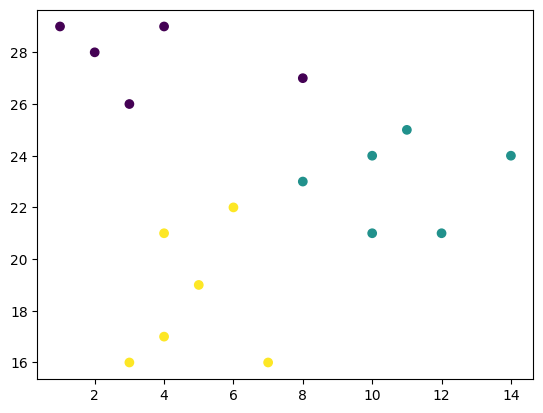

In [4]:
kmeans = KMeans(n_clusters=3)
kmeans.fit(data)

plt.scatter(x, y, c=kmeans.labels_)
plt.show()

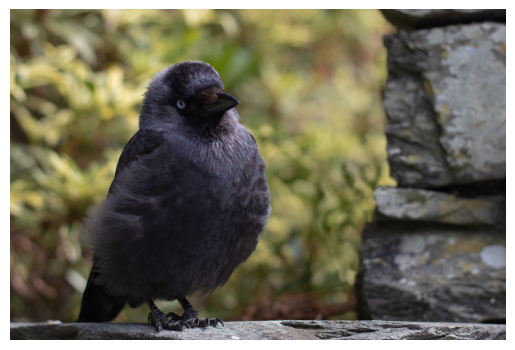

In [5]:
# %pip install opencv-python
import cv2
import numpy as np

img = cv2.imread("bird.jpg")

# swap colour channels so that it is displayed correctly
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) 

# display image
plt.axis('off')
plt.imshow(img)

# split into channels
r, g, b = cv2.split(img)

# reformat pixel colours into 1xn array
r = np.array(r.flatten())
g = np.array(g.flatten())
b = np.array(b.flatten())

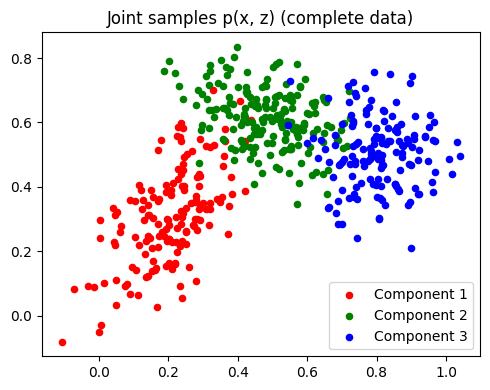

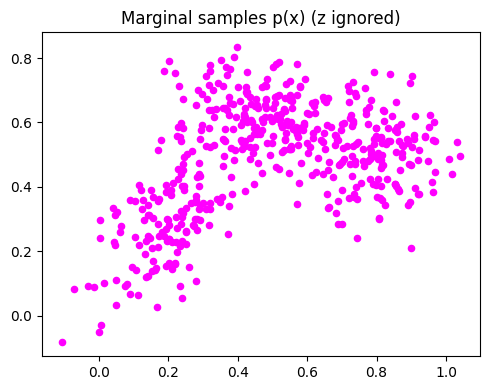

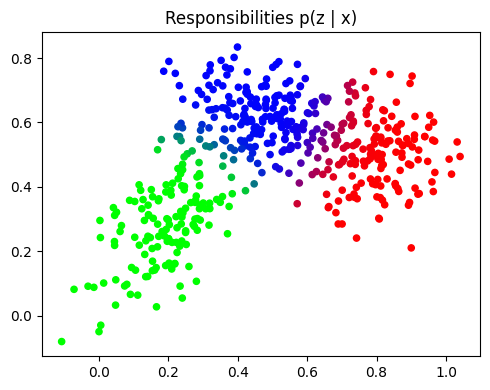

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

np.random.seed(42)

# -----------------------------
# True GMM parameters (ground truth)
# -----------------------------
K = 3
N = 500

# initial mixture weights p(z_k = 1)
pi = np.array([0.3, 0.4, 0.3])

# means and covariances for each component
means = np.array([
    [0.2, 0.3],
    [0.5, 0.6],
    [0.8, 0.5]
])

covs = np.array([
    [[0.01, 0.008], [0.008, 0.02]],
    [[0.015, -0.006], [-0.006, 0.01]],
    [[0.01, 0.0], [0.0, 0.01]]
])

# -----------------------------
# Ancestral sampling
# -----------------------------
# Step 1: sample z ~ p(z)
z = np.random.choice(K, size=N, p=pi)

# Step 2: sample x ~ p(x | z)
X = np.zeros((N, 2))
for k in range(K):
    idx = (z == k)
    X[idx] = np.random.multivariate_normal(
        means[k], covs[k], size=idx.sum()
    )

# -----------------------------
# Figure (a): Joint samples p(x, z)
# -----------------------------
plt.figure(figsize=(5, 4))
colors = ['red', 'green', 'blue']
for k in range(K):
    plt.scatter(X[z == k, 0], X[z == k, 1],
                c=colors[k], label=f'Component {k+1}', s=20)
plt.title("Joint samples p(x, z) (complete data)")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# Figure (b): Marginal samples p(x)
# -----------------------------
plt.figure(figsize=(5, 4))
plt.scatter(X[:, 0], X[:, 1], c='magenta', s=20)
plt.title("Marginal samples p(x) (z ignored)")
plt.tight_layout()
plt.show()

# -----------------------------
# Learn GMM using EM
# -----------------------------
gmm = GaussianMixture(
    n_components=K,
    covariance_type='full',
    random_state=42
)
gmm.fit(X)

# Responsibilities: gamma(z_nk)
responsibilities = gmm.predict_proba(X)

# -----------------------------
# Figure (c): Responsibilities (soft coloring)
# -----------------------------
plt.figure(figsize=(5, 4))
plt.scatter(
    X[:, 0], X[:, 1],
    c=responsibilities,
    s=20
)
plt.title("Responsibilities p(z | x)")
plt.tight_layout()
plt.show()


In [10]:
import numpy as np

# ----------------------------
# 1. Generate synthetic data
# ----------------------------
np.random.seed(42)

N = 500
true_mu = [-2, 3]
true_sigma = [0.5, 1.0]
true_pi = [0.4, 0.6]

z = np.random.choice([0,1], size=N, p=true_pi)
X = np.array([
    np.random.normal(true_mu[k], true_sigma[k])
    for k in z
])

# ----------------------------
# 2. Initialize parameters
# ----------------------------
K = 2
mu = np.random.randn(K)
sigma = np.ones(K)
pi = np.ones(K) / K

def gaussian(x, mu, sigma):
    return (1 / np.sqrt(2*np.pi*sigma**2)) * \
           np.exp(-(x - mu)**2 / (2*sigma**2))

def log_likelihood(X, mu, sigma, pi):
    total = 0
    for x in X:
        mixture = sum(pi[k] * gaussian(x, mu[k], sigma[k]) for k in range(K))
        total += np.log(mixture + 1e-12)
    return total

# ----------------------------
# 3. EM algorithm
# ----------------------------
max_iter = 50

# Track history for convergence plots
ll_history = []
mu_history = []
sigma_history = []
pi_history = []

for iteration in range(max_iter):

    # ---- E STEP ----
    responsibilities = np.zeros((N, K))
    
    for n in range(N):
        for k in range(K):
            responsibilities[n, k] = pi[k] * gaussian(X[n], mu[k], sigma[k])
        responsibilities[n] /= np.sum(responsibilities[n])

    # ---- M STEP ----
    Nk = np.sum(responsibilities, axis=0)

    for k in range(K):
        mu[k] = np.sum(responsibilities[:, k] * X) / Nk[k]
        sigma[k] = np.sqrt(
            np.sum(responsibilities[:, k] * (X - mu[k])**2) / Nk[k]
        )
        pi[k] = Nk[k] / N

    ll = log_likelihood(X, mu, sigma, pi)

    # Store history
    ll_history.append(ll)
    mu_history.append(mu.copy())
    sigma_history.append(sigma.copy())
    pi_history.append(pi.copy())

mu_history = np.array(mu_history)
sigma_history = np.array(sigma_history)
pi_history = np.array(pi_history)

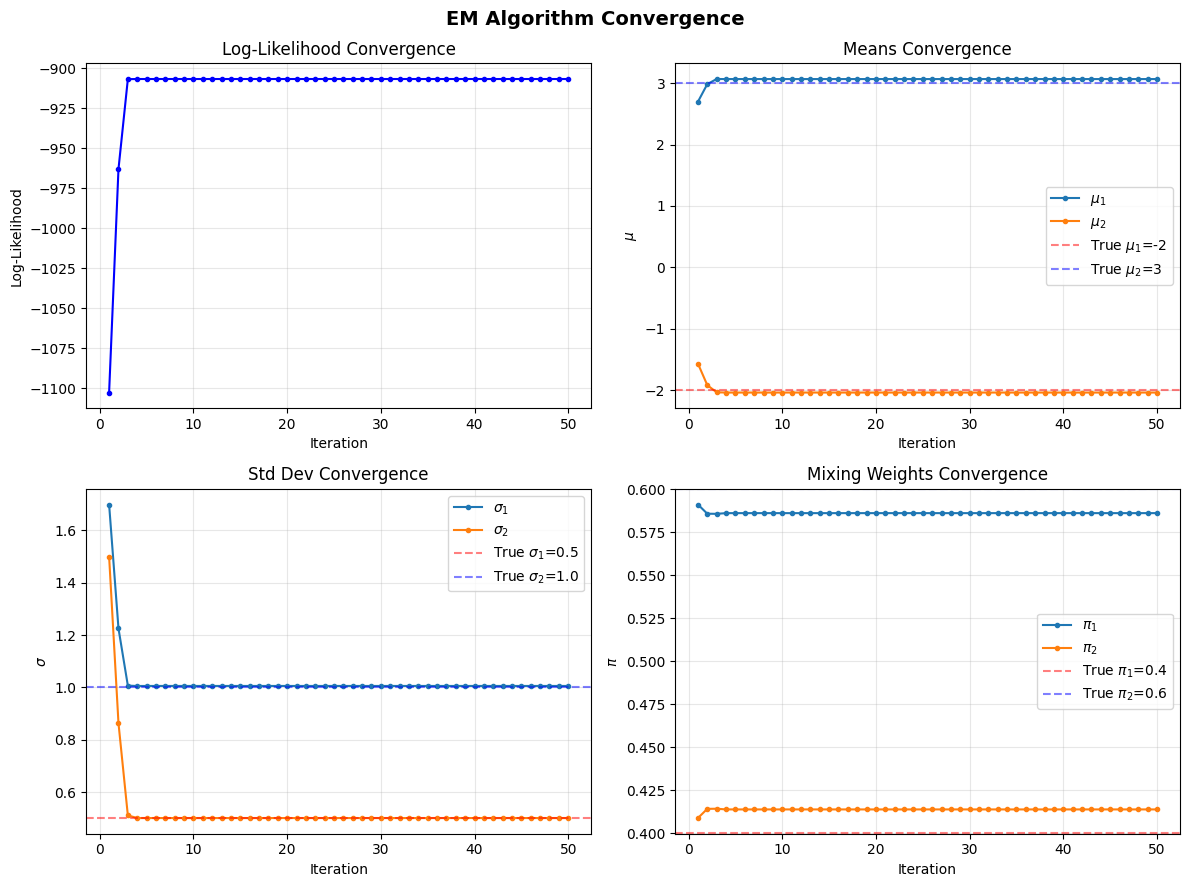

Final estimated parameters:
  mu:    [ 3.06716788 -2.03923494]  (true: [-2, 3])
  sigma: [1.00561592 0.50086728]  (true: [0.5, 1.0])
  pi:    [0.58611767 0.41388233]  (true: [0.4, 0.6])


In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
iters = range(1, max_iter + 1)

# --- Plot 1: Log-Likelihood ---
axes[0, 0].plot(iters, ll_history, 'b-o', markersize=3)
axes[0, 0].set_xlabel('Iteration')
axes[0, 0].set_ylabel('Log-Likelihood')
axes[0, 0].set_title('Log-Likelihood Convergence')
axes[0, 0].grid(True, alpha=0.3)

# --- Plot 2: Means ---
for k in range(K):
    axes[0, 1].plot(iters, mu_history[:, k], '-o', markersize=3, label=f'$\\mu_{k+1}$')
axes[0, 1].axhline(y=true_mu[0], color='red', linestyle='--', alpha=0.5, label=f'True $\\mu_1$={true_mu[0]}')
axes[0, 1].axhline(y=true_mu[1], color='blue', linestyle='--', alpha=0.5, label=f'True $\\mu_2$={true_mu[1]}')
axes[0, 1].set_xlabel('Iteration')
axes[0, 1].set_ylabel('$\\mu$')
axes[0, 1].set_title('Means Convergence')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# --- Plot 3: Standard Deviations ---
for k in range(K):
    axes[1, 0].plot(iters, sigma_history[:, k], '-o', markersize=3, label=f'$\\sigma_{k+1}$')
axes[1, 0].axhline(y=true_sigma[0], color='red', linestyle='--', alpha=0.5, label=f'True $\\sigma_1$={true_sigma[0]}')
axes[1, 0].axhline(y=true_sigma[1], color='blue', linestyle='--', alpha=0.5, label=f'True $\\sigma_2$={true_sigma[1]}')
axes[1, 0].set_xlabel('Iteration')
axes[1, 0].set_ylabel('$\\sigma$')
axes[1, 0].set_title('Std Dev Convergence')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# --- Plot 4: Mixing Weights ---
for k in range(K):
    axes[1, 1].plot(iters, pi_history[:, k], '-o', markersize=3, label=f'$\\pi_{k+1}$')
axes[1, 1].axhline(y=true_pi[0], color='red', linestyle='--', alpha=0.5, label=f'True $\\pi_1$={true_pi[0]}')
axes[1, 1].axhline(y=true_pi[1], color='blue', linestyle='--', alpha=0.5, label=f'True $\\pi_2$={true_pi[1]}')
axes[1, 1].set_xlabel('Iteration')
axes[1, 1].set_ylabel('$\\pi$')
axes[1, 1].set_title('Mixing Weights Convergence')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('EM Algorithm Convergence', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Print final vs true parameters ---
print("Final estimated parameters:")
print(f"  mu:    {mu}  (true: {true_mu})")
print(f"  sigma: {sigma}  (true: {true_sigma})")
print(f"  pi:    {pi}  (true: {true_pi})")